# Test predict-then-optimise baselines

This notebook is a small end-to-end smoke test for `models/src/pto_baselines.py`: load the macro and charge-off data, fit the linear and MLP PTO models on a chronological training sample, and evaluate them out of sample. It is intentionally simple before moving to an expanding-window setup.

In [14]:
from pathlib import Path
import importlib.util
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "models" / "src" / "pto_baselines.py").exists():
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT / "models" / "src"))


import importlib

import capital_allocation_utils
import pto_baselines

importlib.reload(capital_allocation_utils)
importlib.reload(pto_baselines)

from capital_allocation_utils import (
    CapitalConfig,
    ModelConfig,
    chronological_split,
    load_and_align_data,
)

from pto_baselines import (
    PTOForecaster,
    build_prediction_frame,
    evaluate_predictions,
    predict_p,
    run_expanding_window,
    run_holdout,
    train_pto_model,
)

pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", "{:.6f}".format)

ROOT

PosixPath('/homes/heo25/Documents/Decision_Focused_Learning_for_Capital_Allocation')

## Load and align data

`macro_panel_quarterly.csv` is dated at quarter end, while `fred_loan_return_aligned.csv` is dated at quarter start. The temporary macro copy below converts macro dates to quarter start before using the baseline `load_and_align_data` function.

In [15]:
macro_csv = ROOT / "data" / "processed" / "macro_panel_quarterly.csv"
chargeoff_csv = ROOT / "data" / "processed" / "fred_loan_return_aligned.csv"
results_dir = ROOT / "results"
results_dir.mkdir(parents=True, exist_ok=True)

macro = pd.read_csv(macro_csv)
macro["DATE"] = pd.to_datetime(macro["DATE"]).dt.to_period("Q").dt.start_time
macro_aligned_csv = ROOT / "data/processed/" "macro_panel_quarter_start.csv"
macro.to_csv(macro_aligned_csv, index=False)


df = load_and_align_data(
    macro_csv=macro_aligned_csv,
    chargeoff_csv=chargeoff_csv,
    date_col="DATE",
    target_col="charge_off_rate",
    feature_cols=None,
    horizon=1,
    target_is_percent=True,
)

feature_cols = df.attrs["feature_cols"]
print(f"Observations after alignment and one-step target: {len(df)}")
print(f"Date range: {df['DATE'].min().date()} to {df['DATE'].max().date()}")
print(f"Features ({len(feature_cols)}): {feature_cols}")

display(df.head())
display(df.tail())

assert len(df) > 40, "Expected enough quarterly observations for a train/test smoke test."
assert df[feature_cols + ["target_chargeoff_next"]].notna().all().all()

Observations after alignment and one-step target: 143
Date range: 1990-04-01 to 2025-10-01
Features (12): ['real_gdp_growth', 'unemployment_rate', 'industrial_production', 'real_disposable_personal_income', 'cpi', 'house_price_index', 'federal_funds_rate', 'treasury_10y_2y_spread', 'vix', 'corporate_bond_spread', 'senior_loan_officer_survey', 'excess_bond_premium']


,DATE,real_gdp_growth,unemployment_rate,industrial_production,real_disposable_personal_income,cpi,house_price_index,federal_funds_rate,treasury_10y_2y_spread,vix,corporate_bond_spread,senior_loan_officer_survey,excess_bond_premium,charge_off_rate,target_date,target_chargeoff_next
0,1990-04-01,1.500000,5.333333,0.684295,0.736741,0.984464,0.423064,8.243333,0.103016,18.722063,1.638730,54.400000,0.146990,0.014300,1990-07-01,0.012800
1,1990-07-01,0.300000,5.700000,0.386851,0.014248,1.712502,0.607283,8.160000,0.602540,25.195556,1.706190,46.700000,-0.047302,0.012800,1990-10-01,0.013000
2,1990-10-01,-3.600000,6.133333,-1.560018,-0.804251,1.683668,-0.390403,7.743333,0.800161,26.113281,2.197419,54.200000,0.266956,0.013000,1991-01-01,0.014800
3,1991-01-01,-1.900000,6.600000,-1.932577,0.306683,0.744790,0.833014,6.426667,0.987167,22.515833,2.186500,38.600000,0.305454,0.014800,1991-04-01,0.018600
4,1991-04-01,3.200000,6.833333,0.526353,0.748178,0.591864,0.660265,5.863333,1.231406,17.147031,1.795937,20.000000,0.162705,0.018600,1991-07-01,0.019700


,DATE,real_gdp_growth,unemployment_rate,industrial_production,real_disposable_personal_income,cpi,house_price_index,federal_funds_rate,treasury_10y_2y_spread,vix,corporate_bond_spread,senior_loan_officer_survey,excess_bond_premium,charge_off_rate,target_date,target_chargeoff_next
138,2024-10-01,1.900000,4.133333,-0.375669,0.494028,0.782193,0.549054,4.650000,0.130000,17.363231,1.459032,0.000000,-0.327843,0.005200,2025-01-01,0.005500
139,2025-01-01,-0.600000,4.133333,1.036142,0.558128,0.907883,0.737560,4.330000,0.304918,18.521111,1.524918,6.200000,-0.172339,0.005500,2025-04-01,0.005800
140,2025-04-01,3.800000,4.200000,0.451488,0.456883,0.409417,1.481850,4.330000,0.500000,23.561406,1.845161,18.500000,-0.146061,0.005800,2025-07-01,0.005600
141,2025-07-01,4.400000,4.333333,0.530524,0.252105,0.760642,0.572447,4.293333,0.540312,15.983030,1.716875,9.500000,-0.223546,0.005600,2025-10-01,0.005600
142,2025-10-01,0.500000,4.450000,-0.463906,-0.224370,0.712723,0.573424,3.896667,0.577581,17.745231,1.728226,6.500000,-0.228909,0.005600,2026-01-01,0.005900


## Chronological train/test split

The split is deliberately chronological to mimic a real out-of-sample evaluation.

In [16]:
train_frac = 0.75
train_df, test_df = chronological_split(df, train_frac=train_frac)

scaler = StandardScaler()
x_train = scaler.fit_transform(train_df[feature_cols].to_numpy(dtype=float))
x_test = scaler.transform(test_df[feature_cols].to_numpy(dtype=float))
y_train = train_df["target_chargeoff_next"].to_numpy(dtype=float)
y_test = test_df["target_chargeoff_next"].to_numpy(dtype=float)

print(f"Train rows: {len(train_df)} | {train_df['DATE'].min().date()} to {train_df['DATE'].max().date()}")
print(f"Test rows:  {len(test_df)} | {test_df['DATE'].min().date()} to {test_df['DATE'].max().date()}")
print(f"x_train: {x_train.shape}, x_test: {x_test.shape}")

assert x_train.shape[1] == len(feature_cols)
assert len(y_train) == len(train_df)
assert len(y_test) == len(test_df)

Train rows: 107 | 1990-04-01 to 2016-10-01
Test rows:  36 | 2017-01-01 to 2025-10-01
x_train: (107, 12), x_test: (36, 12)


## Train linear and MLP PTO models

The epoch count is modest so this remains quick to rerun while checking whether the pipeline works.

In [54]:
cap_cfg = CapitalConfig(
    leverage=8.0,
    lambda_penalty=10.0,
)
model_cfg = ModelConfig(
    hidden_dim=16,
    lr=1e-3,
    weight_decay=1e-4,
    batch_size=16,
    epochs=300,
    patience=75,
    val_frac=0.2,
    seed=42,
)

pto_predictions, pto_history = run_holdout(
    df=df,
    date_col="DATE",
    feature_cols=feature_cols,
    train_frac=0.75,
    model_cfg=model_cfg,
    cap_cfg=cap_cfg,
    return_history=True,
)

display(pto_predictions.head())
display(pto_history.head())

Train observations: 107 | Test observations: 36
    linear epoch    1 | val mse 0.00005383 | val regret 0.033793 | mean p 0.5421 | mean alpha 0.4545
    linear epoch  100 | val mse 0.00005107 | val regret 0.033420 | mean p 0.5262 | mean alpha 0.4562
    linear epoch  200 | val mse 0.00004667 | val regret 0.032616 | mean p 0.4855 | mean alpha 0.4601
    linear epoch  300 | val mse 0.00004279 | val regret 0.031885 | mean p 0.4479 | mean alpha 0.4638

LINEAR PTO HOLDOUT
  rmse_chargeoff: 0.00426044
  mae_chargeoff: 0.00381845
  mean_regret: 0.02363758
  median_regret: 0.02245259
  mean_alpha: 0.49818186
  mean_oracle_alpha: 0.61943971
    mlp    epoch    1 | val mse 0.00005294 | val regret 0.033871 | mean p 0.5404 | mean alpha 0.4542
    mlp    epoch  100 | val mse 0.00003926 | val regret 0.029910 | mean p 0.3940 | mean alpha 0.4734
    mlp    epoch  200 | val mse 0.00003898 | val regret 0.028693 | mean p 0.3726 | mean alpha 0.4794

MLP PTO HOLDOUT
  rmse_chargeoff: 0.00382890
  mae_charg

,feature_date,target_date,model,eval_mode,realised_chargeoff,p_hat_stress,mu_hat_chargeoff,pd_hat_annualised,k_irb_hat,alpha_hat,alpha_oracle,realised_utility,oracle_utility,regret
0,2017-01-01,2017-04-01,linear,holdout,0.003700,0.144630,0.007286,0.063208,0.130111,0.495934,0.611064,1.096410,1.118442,0.022033
1,2017-04-01,2017-07-01,linear,holdout,0.003400,0.111587,0.007015,0.060913,0.128384,0.501293,0.619380,1.098655,1.121527,0.022873
2,2017-07-01,2017-10-01,linear,holdout,0.003600,0.100517,0.006924,0.060143,0.127799,0.503284,0.613776,1.098241,1.119454,0.021214
3,2017-10-01,2018-01-01,linear,holdout,0.003000,0.025774,0.006311,0.054932,0.123782,0.522878,0.631466,1.104576,1.125899,0.021324
4,2018-01-01,2018-04-01,linear,holdout,0.002700,0.041418,0.006440,0.056024,0.124633,0.517483,0.641542,1.104739,1.129432,0.024693


,epoch,model,train_loss,val_loss,val_rmse_chargeoff,val_mae_chargeoff,val_mean_regret,val_median_regret,val_max_regret,val_mean_p_hat,val_mean_mu_hat,val_mean_alpha,val_mean_oracle_alpha,eval_mode
0,1,linear,0.000034,0.000054,0.007337,0.007203,0.033793,0.032761,0.049357,0.542143,0.010546,0.454543,0.626196,holdout
1,2,linear,0.000033,0.000054,0.007338,0.007206,NaN,NaN,NaN,0.542560,0.010549,NaN,NaN,holdout
2,3,linear,0.000033,0.000054,0.007339,0.007210,NaN,NaN,NaN,0.543005,0.010553,NaN,NaN,holdout
3,4,linear,0.000032,0.000054,0.007340,0.007213,NaN,NaN,NaN,0.543438,0.010556,NaN,NaN,holdout
4,5,linear,0.000032,0.000054,0.007341,0.007217,NaN,NaN,NaN,0.543848,0.010560,NaN,NaN,holdout


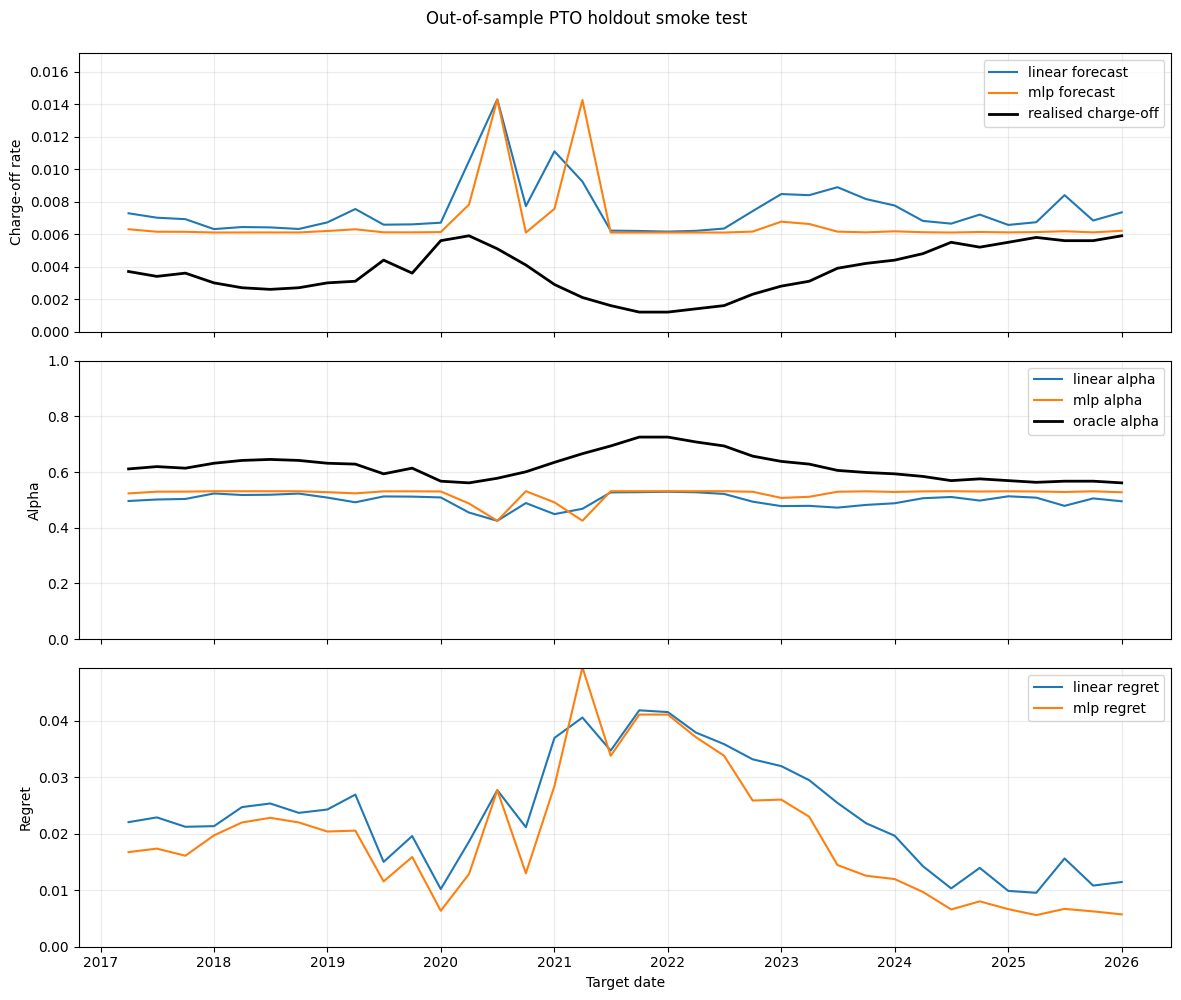

In [55]:

pto_predictions["target_date"] = pd.to_datetime(pto_predictions["target_date"])

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

for model_name, group in pto_predictions.groupby("model"):
    group = group.sort_values("target_date")

    axes[0].plot(
        group["target_date"],
        group["mu_hat_chargeoff"],
        label=f"{model_name} forecast",
    )

    axes[1].plot(
        group["target_date"],
        group["alpha_hat"],
        label=f"{model_name} alpha",
    )

    axes[2].plot(
        group["target_date"],
        group["regret"],
        label=f"{model_name} regret",
    )

# Oracle / realised values are the same across model rows, so take one model
oracle = (
    pto_predictions[pto_predictions["model"] == "linear"]
    .sort_values("target_date")
)

axes[0].plot(
    oracle["target_date"],
    oracle["realised_chargeoff"],
    color="black",
    linewidth=2,
    label="realised charge-off",
)

axes[1].plot(
    oracle["target_date"],
    oracle["alpha_oracle"],
    color="black",
    linewidth=2,
    label="oracle alpha",
)

# Optional close-up axes
axes[0].set_ylim(
    0.0,
    max(
        pto_predictions["mu_hat_chargeoff"].max(),
        pto_predictions["realised_chargeoff"].max(),
    ) * 1.2,
)

axes[1].set_ylim(0.0, 1.0)
axes[2].set_ylim(0.0, pto_predictions["regret"].quantile(0.95) * 1.2)

axes[0].set_ylabel("Charge-off rate")
axes[1].set_ylabel("Alpha")
axes[2].set_ylabel("Regret")
axes[2].set_xlabel("Target date")

for ax in axes:
    ax.grid(True, alpha=0.25)
    ax.legend(loc="best")

fig.suptitle("Out-of-sample PTO holdout smoke test", y=0.995)
plt.tight_layout()
plt.show()



In [ ]:
run_expanding_smoke_test = True

if run_expanding_smoke_test:
    expanding_cfg = ModelConfig(
        hidden_dim=16,
        lr=1e-3,
        weight_decay=1e-4,
        batch_size=16,
        epochs=100,
        patience=25,
        val_frac=0.2,
        seed=42,
    )

    pto_expanding_predictions, pto_expanding_history = run_expanding_window(
        df=df,
        date_col="DATE",
        feature_cols=feature_cols,
        initial_train_frac=0.75,
        model_cfg=expanding_cfg,
        cap_cfg=cap_cfg,
        return_history=True,
    )

    display(pto_expanding_predictions.head())
    display(pto_expanding_history.head())

Initial train observations: 71 | Expanding-window test observations: 72
  expanding step 1/72: train through index 70, test index 71
    fitting linear PTO model...
    linear epoch    1 | val mse 0.00004374 | val regret 0.030729 | mean p 0.4938 | mean alpha 0.4594
    linear epoch  100 | val mse 0.00002396 | val regret 0.026865 | mean p 0.2958 | mean alpha 0.4788
    fitting mlp PTO model...
    mlp    epoch    1 | val mse 0.00004097 | val regret 0.030596 | mean p 0.4647 | mean alpha 0.4605
    mlp    epoch  100 | val mse 0.00001053 | val regret 0.019069 | mean p 0.0713 | mean alpha 0.5188
  expanding step 10/72: train through index 79, test index 80
    fitting linear PTO model...
    linear epoch    1 | val mse 0.00006844 | val regret 0.090014 | mean p 0.4937 | mean alpha 0.4602
    linear epoch  100 | val mse 0.00003319 | val regret 0.018225 | mean p 0.6304 | mean alpha 0.4531
    fitting mlp PTO model...
    mlp    epoch    1 | val mse 0.00006867 | val regret 0.057369 | mean p 0.5

,feature_date,target_date,model,eval_mode,realised_chargeoff,p_hat_stress,mu_hat_chargeoff,pd_hat_annualised,k_irb_hat,alpha_hat,alpha_oracle,realised_utility,oracle_utility,regret
0,2008-01-01,2008-04-01,linear,expanding,0.008400,0.937986,0.013791,0.117070,0.163503,0.428093,0.517877,1.067125,1.081040,0.013915
1,2008-01-01,2008-04-01,mlp,expanding,0.008400,0.998035,0.014284,0.121049,0.165410,0.424966,0.517877,1.066635,1.081040,0.014405
2,2008-04-01,2008-07-01,linear,expanding,0.010300,0.935897,0.013774,0.116931,0.163435,0.428205,0.492198,1.060634,1.069575,0.008941
3,2008-04-01,2008-07-01,mlp,expanding,0.010300,0.999439,0.014295,0.121142,0.165454,0.424895,0.492198,1.060165,1.069575,0.009409
4,2008-07-01,2008-10-01,linear,expanding,0.012700,0.921923,0.013660,0.116003,0.162979,0.428960,0.466553,1.052505,1.057025,0.004520


,epoch,model,train_loss,val_loss,val_rmse_chargeoff,val_mae_chargeoff,val_mean_regret,val_median_regret,val_max_regret,val_mean_p_hat,val_mean_mu_hat,val_mean_alpha,val_mean_oracle_alpha,expanding_step,feature_date,target_date
0,1,linear,0.000042,0.000044,0.006614,0.006477,0.030729,0.032371,0.041351,0.493757,0.010149,0.459369,0.617322,1,2008-01-01,2008-04-01
1,2,linear,0.000041,0.000043,0.006590,0.006456,NaN,NaN,NaN,0.491165,0.010128,NaN,NaN,1,2008-01-01,2008-04-01
2,3,linear,0.000041,0.000043,0.006566,0.006435,NaN,NaN,NaN,0.488560,0.010106,NaN,NaN,1,2008-01-01,2008-04-01
3,4,linear,0.000040,0.000043,0.006542,0.006413,NaN,NaN,NaN,0.485950,0.010085,NaN,NaN,1,2008-01-01,2008-04-01
4,5,linear,0.000040,0.000042,0.006518,0.006392,NaN,NaN,NaN,0.483337,0.010063,NaN,NaN,1,2008-01-01,2008-04-01


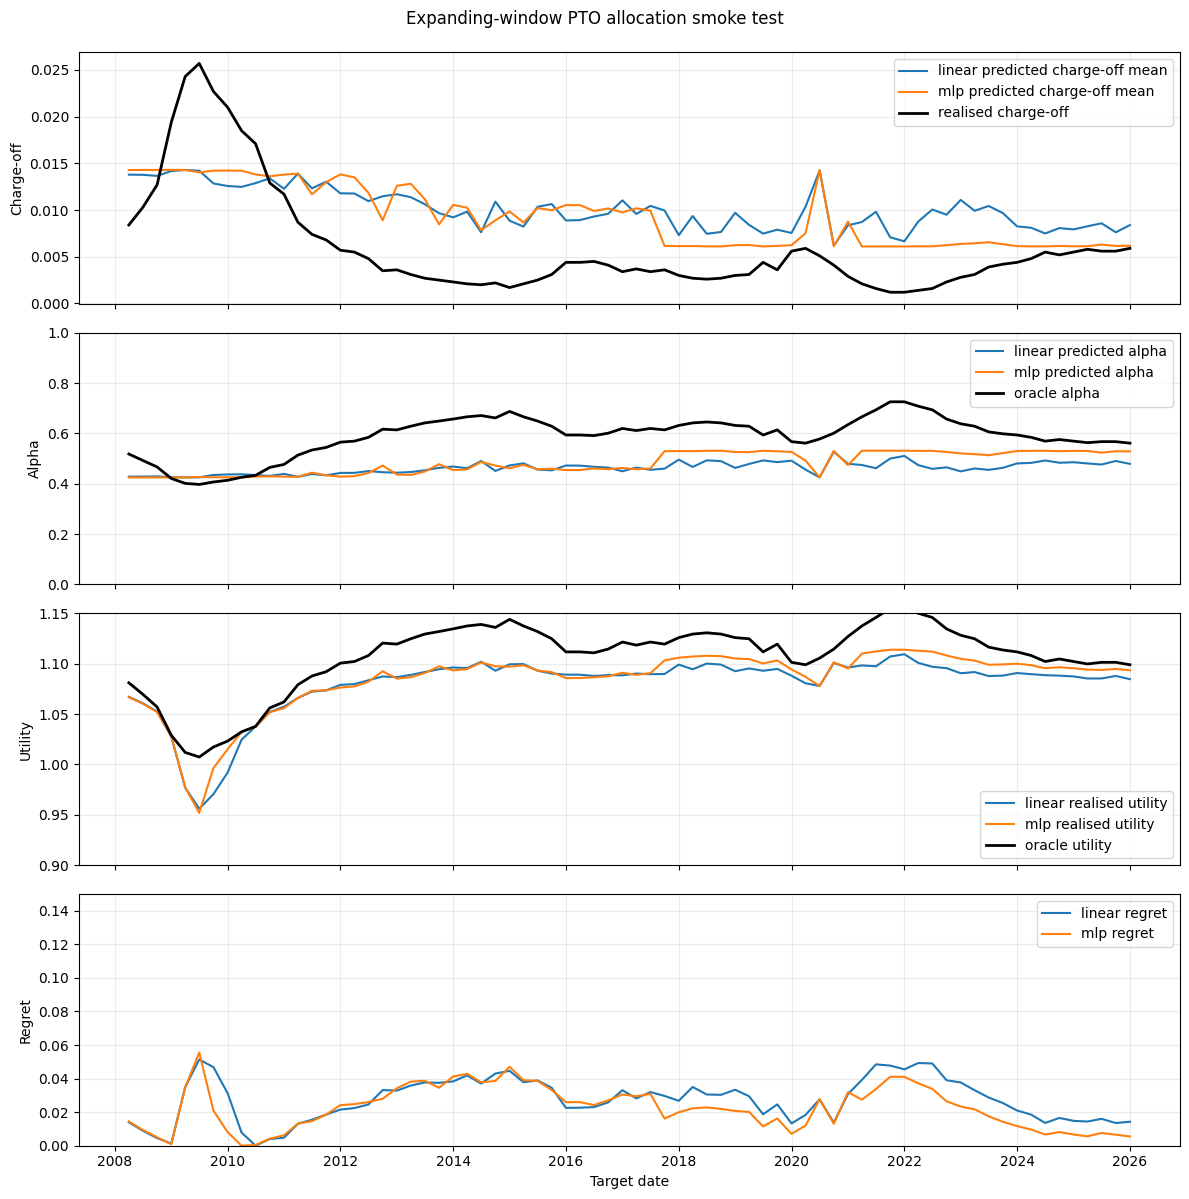

In [63]:
pto_expanding_predictions["target_date"] = pd.to_datetime(
    pto_expanding_predictions["target_date"]
)

fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

for model_name, group in pto_expanding_predictions.groupby("model"):
    group = group.sort_values("target_date")

    axes[0].plot(
        group["target_date"],
        group["mu_hat_chargeoff"],
        label=f"{model_name} predicted charge-off mean",
    )

    axes[1].plot(
        group["target_date"],
        group["alpha_hat"],
        label=f"{model_name} predicted alpha",
    )

    axes[2].plot(
        group["target_date"],
        group["realised_utility"],
        label=f"{model_name} realised utility",
    )

    axes[3].plot(
        group["target_date"],
        group["regret"],
        label=f"{model_name} regret",
    )

oracle = (
    pto_expanding_predictions[pto_expanding_predictions["model"] == "linear"]
    .sort_values("target_date")
)

axes[0].plot(
    oracle["target_date"],
    oracle["realised_chargeoff"],
    color="black",
    linewidth=2,
    label="realised charge-off",
)

axes[1].plot(
    oracle["target_date"],
    oracle["alpha_oracle"],
    color="black",
    linewidth=2,
    label="oracle alpha",
)

axes[2].plot(
    oracle["target_date"],
    oracle["oracle_utility"],
    color="black",
    linewidth=2,
    label="oracle utility",
)

axes[1].set_ylim(0.0, 1.0)
axes[2].set_ylim(0.9, 1.15)
axes[3].set_ylim(0.0, 0.15)

axes[0].set_ylabel("Charge-off")
axes[1].set_ylabel("Alpha")
axes[2].set_ylabel("Utility")
axes[3].set_ylabel("Regret")
axes[3].set_xlabel("Target date")

for ax in axes:
    ax.grid(True, alpha=0.25)
    ax.legend(loc="best")

fig.suptitle("Expanding-window PTO allocation smoke test", y=0.995)
plt.tight_layout()
plt.show()

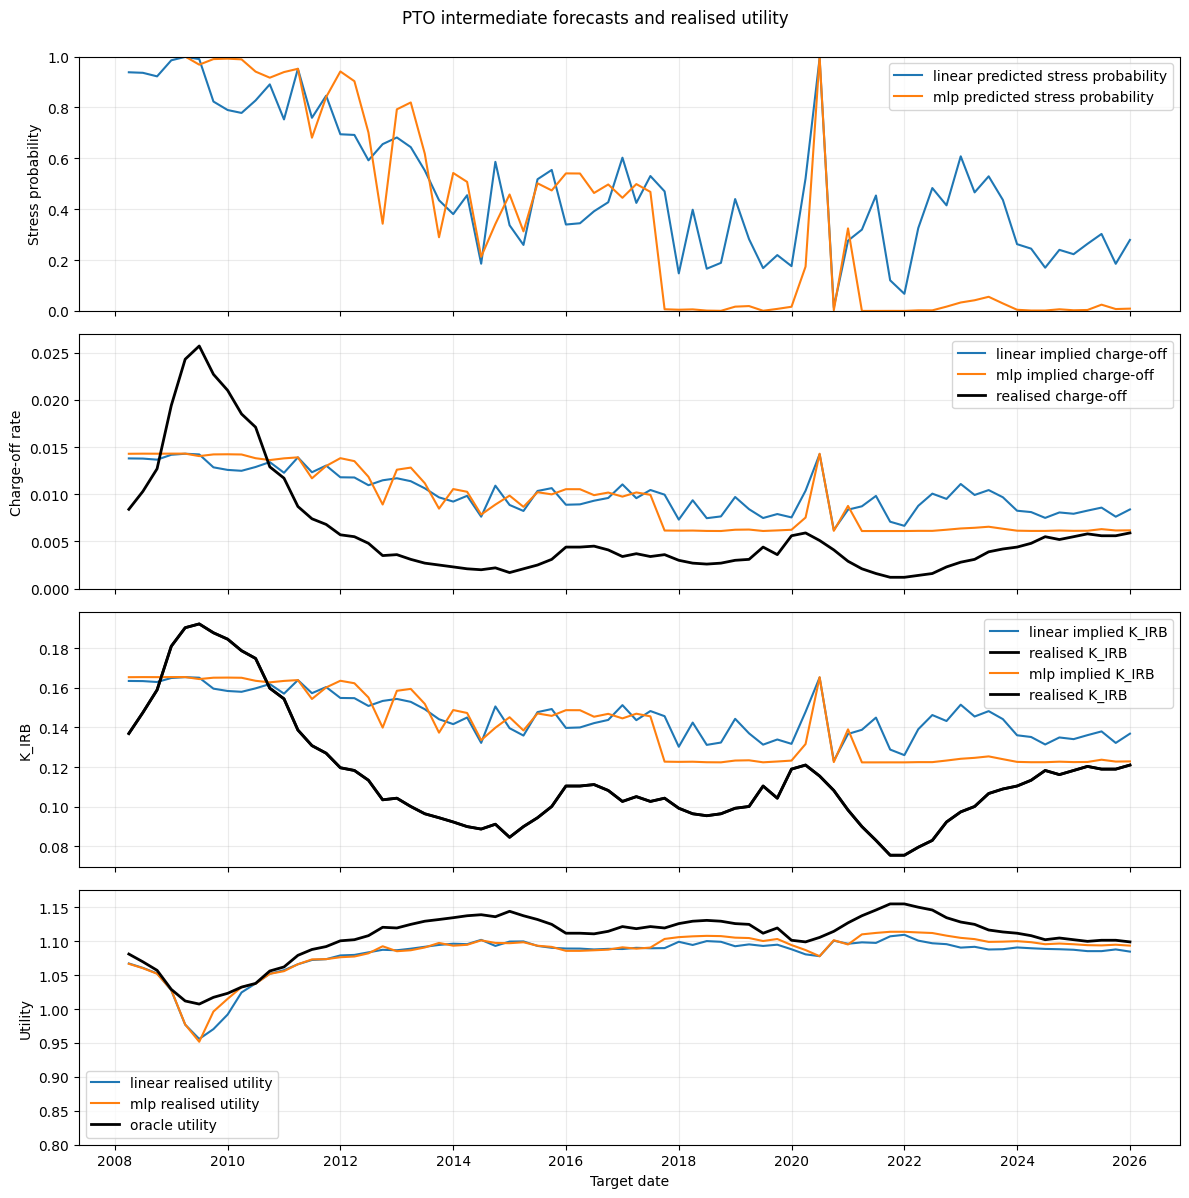

In [66]:

from capital_allocation_utils import annualised_pd_from_chargeoff, irb_capital_requirement

oracle = pto_expanding_predictions[
    pto_expanding_predictions["model"] == "linear"
].sort_values("target_date").copy()

pd_realised = annualised_pd_from_chargeoff(
    oracle["realised_chargeoff"].to_numpy(dtype=float),
    cap_cfg,
)

oracle["k_irb_realised"] = irb_capital_requirement(pd_realised, cap_cfg)
pto_expanding_predictions["target_date"] = pd.to_datetime(
    pto_expanding_predictions["target_date"]
)

fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

for model_name, group in pto_expanding_predictions.groupby("model"):
    group = group.sort_values("target_date")

    # 1. Predicted stress probability
    axes[0].plot(
        group["target_date"],
        group["p_hat_stress"],
        label=f"{model_name} predicted stress probability",
    )

    # 2. Implied charge-off mean
    axes[1].plot(
        group["target_date"],
        group["mu_hat_chargeoff"],
        label=f"{model_name} implied charge-off",
    )

    # 3. Implied Basel IRB capital requirement
    axes[2].plot(
        group["target_date"],
        group["k_irb_hat"],
        label=f"{model_name} implied K_IRB",
    )
    axes[2].plot(
    oracle["target_date"],
    oracle["k_irb_realised"],
    color="black",
    linewidth=2,
    label="realised K_IRB",
)
    # 4. Realised utility
    axes[3].plot(
        group["target_date"],
        group["realised_utility"],
        label=f"{model_name} realised utility",
    )

# Realised/oracle series are the same across model rows, so take one model
oracle = (
    pto_expanding_predictions[pto_expanding_predictions["model"] == "linear"]
    .sort_values("target_date")
)

# Add realised charge-off to implied charge-off panel
axes[1].plot(
    oracle["target_date"],
    oracle["realised_chargeoff"],
    color="black",
    linewidth=2,
    label="realised charge-off",
)

# Add oracle utility to utility panel
axes[3].plot(
    oracle["target_date"],
    oracle["oracle_utility"],
    color="black",
    linewidth=2,
    label="oracle utility",
)

axes[0].set_ylabel("Stress probability")
axes[1].set_ylabel("Charge-off rate")
axes[2].set_ylabel("K_IRB")
axes[3].set_ylabel("Utility")
axes[3].set_xlabel("Target date")

axes[0].set_ylim(0.0, 1.0)
axes[3].set_ylim(0.8, 1.175)  # optional close-up for utility

for ax in axes:
    ax.grid(True, alpha=0.25)
    ax.legend(loc="best")

fig.suptitle("PTO intermediate forecasts and realised utility", y=0.995)
plt.tight_layout()
plt.show()

## Save optional outputs

This gives you a small CSV to inspect or compare against future expanding-window results.

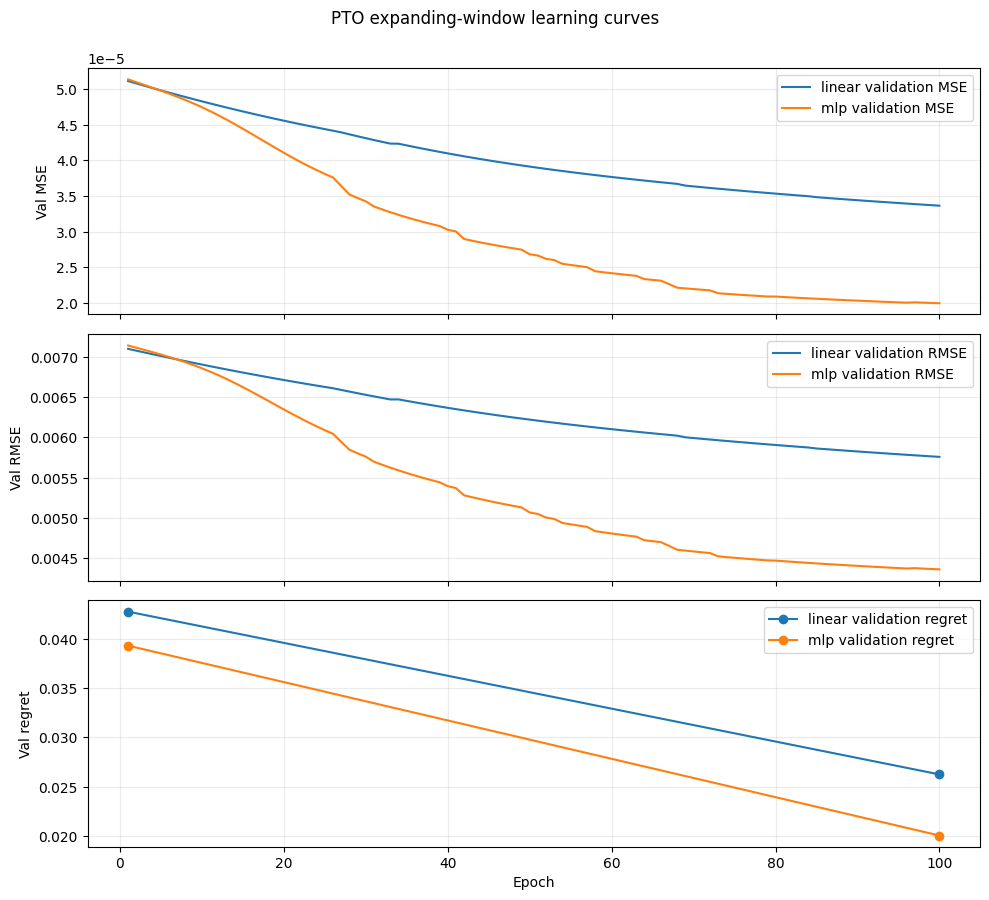

In [ ]:
regret_history = mean_history.dropna(subset=["mean_val_regret"])

fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

for model_name, group in mean_history.groupby("model"):
    group = group.sort_values("epoch")

    axes[0].plot(
        group["epoch"],
        group["mean_val_loss"],
        label=f"{model_name} validation MSE",
    )

    axes[1].plot(
        group["epoch"],
        group["mean_val_rmse"],
        label=f"{model_name} validation RMSE",
    )

for model_name, group in regret_history.groupby("model"):
    group = group.sort_values("epoch")

    axes[2].plot(
        group["epoch"],
        group["mean_val_regret"],
        marker="o",
        label=f"{model_name} validation regret",
    )

axes[0].set_ylabel("Val MSE")
axes[1].set_ylabel("Val RMSE")
axes[2].set_ylabel("Val regret")
axes[2].set_xlabel("Epoch")

for ax in axes:
    ax.grid(True, alpha=0.25)
    ax.legend(loc="best")

fig.suptitle("PTO expanding-window learning curves", y=0.995)
plt.tight_layout()
plt.show()

In [73]:
print("Train target summary:")
display(train_df["target_chargeoff_next"].describe())

print("Test target summary:")
display(test_df["target_chargeoff_next"].describe())

print("Current mixture params:")
print("mu_normal:", cap_cfg.mu_normal)
print("mu_stress:", cap_cfg.mu_stress)
print("sigma_normal:", cap_cfg.sigma_normal)
print("sigma_stress:", cap_cfg.sigma_stress)

print("Share of train target below mu_normal:")
print((train_df["target_chargeoff_next"] < cap_cfg.mu_normal).mean())

print("Share of test target below mu_normal:")
print((test_df["target_chargeoff_next"] < cap_cfg.mu_normal).mean())

Train target summary:


count   107.000000
mean      0.007833
std       0.006247
min       0.001200
25%       0.003050
50%       0.005400
75%       0.012550
max       0.025700
Name: target_chargeoff_next, dtype: float64

Test target summary:


count   36.000000
mean     0.003697
std      0.001472
min      0.001200
25%      0.002700
50%      0.003600
75%      0.005125
max      0.005900
Name: target_chargeoff_next, dtype: float64

Current mixture params:
mu_normal: 0.0061
mu_stress: 0.0143
sigma_normal: 0.0042
sigma_stress: 0.0067
Share of train target below mu_normal:
0.5700934579439252
Share of test target below mu_normal:
1.0


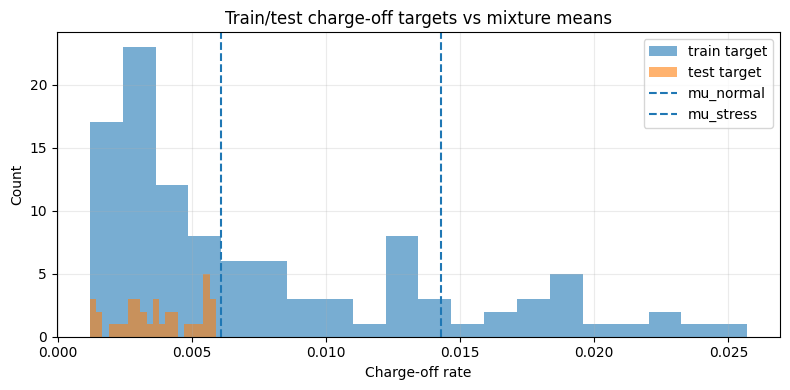

In [74]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(
    train_df["target_chargeoff_next"],
    bins=20,
    alpha=0.6,
    label="train target",
)

ax.hist(
    test_df["target_chargeoff_next"],
    bins=20,
    alpha=0.6,
    label="test target",
)

ax.axvline(cap_cfg.mu_normal, linestyle="--", label="mu_normal")
ax.axvline(cap_cfg.mu_stress, linestyle="--", label="mu_stress")

ax.set_xlabel("Charge-off rate")
ax.set_ylabel("Count")
ax.set_title("Train/test charge-off targets vs mixture means")
ax.legend()
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig('figures/test_distribution.png')
plt.show()


## Save optional outputs

This gives you a small CSV to inspect or compare against future expanding-window results.

In [ ]:
output_csv = scratch_dir / "pto_baseline_smoke_test_predictions.csv"
predictions.to_csv(output_csv, index=False)
print(f"Saved predictions to {output_csv.relative_to(ROOT)}")